# 12. キャップストーン:1つの回帰、3つのレンズ(線形代数の視点)

ここまで3冊で別々に学んだ道具が、実は**同じ1つの問題の別の顔**だったことを体験する。

題材は共通の回帰問題:真の曲線 $f(x) = \sin(1.5x) + 0.3x$ にノイズを乗せたデータを、多項式でフィットする。3冊がまったく同じデータ(`make_capstone_dataset`、同一実装)を使う。

- **この章(線形代数)** — 解そのものを *閉形式の幾何* として見る:正規方程式・SVD・リッジ
- 次に **ニューラルネット** が、同じ解へ *勾配降下で辿り着く* 過程を見せる
- 最後に **ベイズ** が、その解の *周りの不確実性* を与える

貫く一行: **リッジ回帰 = 正規事前の MAP = ベイズ線形回帰の事後平均**。

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio

from la_book import plotting as viz
from la_book.algebra import least_squares, ridge
from la_book.datasets import make_capstone_dataset

pio.renderers.default = "plotly_mimetype+notebook_connected"

x, y = make_capstone_dataset(seed=0)
x_grid = np.linspace(x.min(), x.max(), 200)
f_true = np.sin(1.5 * x_grid) + 0.3 * x_grid
print(f'{len(x)} points on x in [{x.min():.2f}, {x.max():.2f}]')

40 points on x in [-2.98, 2.98]


## データと多項式特徴

$x$ を $[\,1,\ x,\ x^2,\ \dots,\ x^d\,]$ に写すと、非線形フィットが**特徴量に対しては線形**な回帰になる。設計行列を $\Phi$ と書く(高次列は標準化して桁を揃える)。

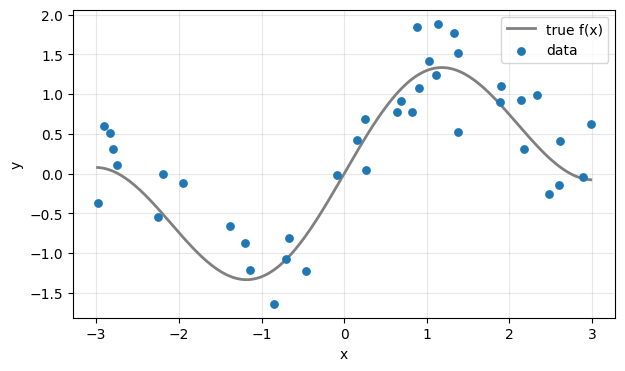

In [2]:
def poly_features(x, degree, stats=None):
    """Polynomial design matrix; standardize non-constant columns (stable fits).

    Returns (Phi, stats); pass stats back to transform a fresh grid the same way.
    """
    X = np.vander(np.asarray(x, dtype=float), degree + 1, increasing=True)
    if stats is None:
        mu, sd = X[:, 1:].mean(0), X[:, 1:].std(0)
    else:
        mu, sd = stats
    Xs = X.copy()
    Xs[:, 1:] = (X[:, 1:] - mu) / sd
    return Xs, (mu, sd)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_grid, f_true, color='gray', lw=2, label='true f(x)')
ax.scatter(x, y, s=28, color='#1f77b4', zorder=3, label='data')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel('x'); ax.set_ylabel('y');

## 正則化なしの最小二乗は高次で暴れる

次数を上げると訓練点は通るが、点の間で激しく振動する(過適合)。$\min_w \lVert \Phi w - y\rVert^2$ を QR で解く。

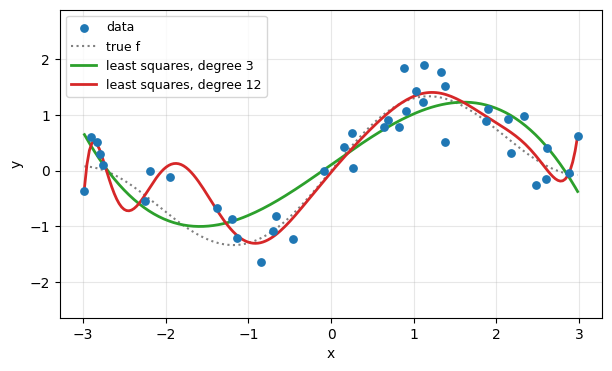

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=28, color='#1f77b4', zorder=3, label='data')
ax.plot(x_grid, f_true, color='gray', lw=1.5, ls=':', label='true f')
for degree, color in [(3, '#2ca02c'), (12, '#d62728')]:
    Phi, stats = poly_features(x, degree)
    w_ls, _res = least_squares(Phi, y)
    Phi_g, _ = poly_features(x_grid, degree, stats)
    ax.plot(x_grid, Phi_g @ w_ls, color=color, lw=2, label=f'least squares, degree {degree}')
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlabel('x'); ax.set_ylabel('y');

## なぜ暴れるのか:SVD と条件数

$\Phi = U \Sigma V^\top$。小さな特異値の方向は、データのわずかなノイズを巨大な係数に増幅する。条件数 $\sigma_{\max}/\sigma_{\min}$ が大きいほど解は不安定になる。

In [4]:
Phi12, _ = poly_features(x, 12)
s = np.linalg.svd(Phi12, compute_uv=False)
print(f'degree 12: condition number = {s[0] / s[-1]:.3e}')
# Interactive: energy per singular value and cumulative energy (slider over rank k).
fig = viz.plotly_svd_spectrum(Phi12, title='Phi spectrum (degree 12)')
fig.show()

degree 12: condition number = 1.140e+04


## リッジ正則化が安定させる

$w^\star = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top y$。$\lambda I$ を足すと小さい特異値が底上げされ、増幅が抑えられる。大きい $\lambda$ ほど係数が原点へ縮む(係数ノルムを見る)。

||w|| least squares =   233.48
||w|| ridge (1.0)   =     2.09


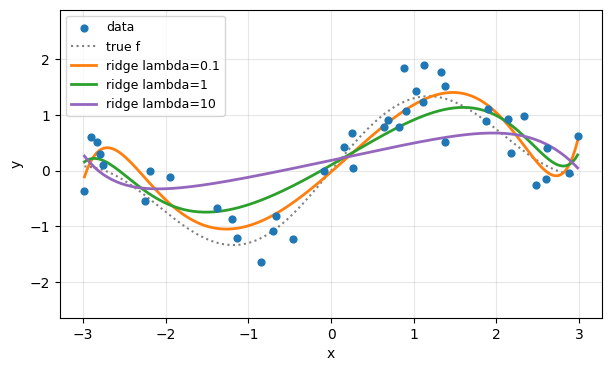

In [5]:
degree = 12
Phi, stats = poly_features(x, degree)
Phi_g, _ = poly_features(x_grid, degree, stats)
w_ls, _ = least_squares(Phi, y)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=24, color='#1f77b4', zorder=3, label='data')
ax.plot(x_grid, f_true, color='gray', lw=1.5, ls=':', label='true f')
for lam, color in [(0.1, '#ff7f0e'), (1.0, '#2ca02c'), (10.0, '#9467bd')]:
    w = ridge(Phi, y, lam)
    ax.plot(x_grid, Phi_g @ w, color=color, lw=2, label=f'ridge lambda={lam:g}')
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlabel('x'); ax.set_ylabel('y')
print(f'||w|| least squares = {np.linalg.norm(w_ls):8.2f}')
print(f'||w|| ridge (1.0)   = {np.linalg.norm(ridge(Phi, y, 1.0)):8.2f}')

## 橋渡し

いま得た $w^\star = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top y$ は、線形代数では**一発で**求まる。

- **ニューラルネット**は、この同じ $w^\star$ に *勾配降下* で少しずつ近づく(weight decay = $\lambda$ 項)
- **ベイズ**は、$w$ に事前 $\mathcal N(0,\sigma_w^2 I)$ を置き、$w^\star$ を *事後分布の平均* として得る($\lambda = \sigma^2/\sigma_w^2$)。さらに平均の周りの *分散* が予測の不確実性になる

同じ地形を3方向から照らしている。

## 3つのレンズへのリンク

同じデータ・同じ答えを、3冊が別の角度から照らす。

- **線形代数** — `analytics/linear_algebra` 12章「キャップストーン」:正規方程式の閉形式解・SVD・リッジ
- **ニューラルネット** — `analytics/neural_net` 14章「キャップストーン」:勾配降下が同じ解に辿り着く
- **ベイズ** — `analytics/bayesian` 13章「キャップストーン」:重みの事後分布と予測の不確実性

3視点を並べたショーケールは統合ポータル(`analytics/report`、`make report`)の「統合」ページにもある。